# Prueba de Progreso 1 - Predicción de la Calidad del Vino: Clasificación vs Regresión

**Autor:** Jorge López Gómez  
**Email:** [Jorge.Lopez32@alu.uclm.es](mailto:Jorge.Lopez32@alu.uclm.es)  
**Asignatura:** Técnicas de Aprendizaje Automático  
**Curso:** 2025/2026  
**Universidad:** UCLM — Talavera de la Reina  
**Fecha:** Marzo 2026  
**Repositorio:** [github.com/JorgeLopezGomez/ML-TA-2025-2026-JorgeLopezGomez](https://github.com/JorgeLopezGomez/ML-TA-2025-2026-JorgeLopezGomez)

---

## 1. Introducción

En este cuaderno vamos a trabajar con el dataset [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) del repositorio UCI, que recoge muestras de vinos tintos y blancos de la variedad portuguesa "Vinho Verde". El dataset fue publicado por Cortez et al. (2009) y contiene 11 variables fisicoquímicas de entrada (acidez, pH, alcohol, etc.) junto con una puntuación de calidad otorgada por expertos catadores en una escala de 0 a 10.

El objetivo principal de esta práctica es doble:
1. Predecir la calidad del vino como **variable continua** (regresión).
2. Predecir la calidad del vino como **variable categórica** (clasificación).

Para cada enfoque voy a probar **tres algoritmos** distintos, comparar su rendimiento y quedarme con el mejor de cada uno. Al final, haré una comparación entre el mejor modelo de regresión y el mejor de clasificación para sacar conclusiones sobre qué aproximación se ajusta mejor a este problema.

Los algoritmos que he decidido probar son:
- **Random Forest** (tanto clasificación como regresión): es un método de ensemble que suele dar buenos resultados sin necesidad de mucho ajuste de hiperparámetros.
- **SVM** (Support Vector Machine): funciona bien en espacios de alta dimensionalidad y es bastante robusto.
- **KNN** (K-Nearest Neighbors): un método sencillo basado en la distancia que puede servir como baseline interesante.

He elegido estos tres porque cubren distintas familias de algoritmos (ensemble, kernel, basado en instancias), así puedo ver cuál se adapta mejor a la naturaleza de los datos.

## 2. Carga de librerías y datos

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    f1_score, ConfusionMatrixDisplay
)

# Algoritmos de regresión
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Algoritmos de clasificación
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [39]:
from ucimlrepo import fetch_ucirepo

# Descarga del dataset
wine_quality = fetch_ucirepo(id=186)

# Datos brutos en formato Dataframe de pandas
X = wine_quality.data.features
y = wine_quality.data.targets

print(f'Características (X): {X.shape}')
print(f'Objetivo (y): {y.shape}')

Características (X): (6497, 11)
Objetivo (y): (6497, 1)


In [40]:
# Juntamos todo en un solo dataframe para explorar
df = pd.concat([X, y], axis=1)
print(f'Tamaño total del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head(10)

Tamaño total del dataset: 6497 filas x 12 columnas


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


## 3. Análisis Exploratorio de Datos (EDA)

Antes de meter mano a los modelos, toca echar un vistazo a los datos para entender con qué estamos trabajando. Vamos a ver la distribución de las variables, si hay valores faltantes, y cómo se relacionan las características con la calidad.

In [41]:
# Info general del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


In [42]:
# Estadísticas descriptivas
df.describe().round(3)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000
mean,7.215,0.340,0.319,5.443,0.056,30.525,115.745,0.995,3.219,0.531,10.492,5.818
std,1.296,0.165,0.145,4.758,0.035,17.749,56.522,0.003,0.161,0.149,1.193,0.873
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.720,0.220,8.000,3.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,77.000,0.992,3.110,0.430,9.500,5.000
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300,6.000
75%,7.700,0.400,0.390,8.100,0.065,41.000,156.000,0.997,3.320,0.600,11.300,6.000
max,15.900,1.580,1.660,65.800,0.611,289.000,440.000,1.039,4.010,2.000,14.900,9.000


In [43]:
# Comprobamos que no hay valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nTotal de valores nulos: {df.isnull().sum().sum()}')

Valores nulos por columna:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total de valores nulos: 0


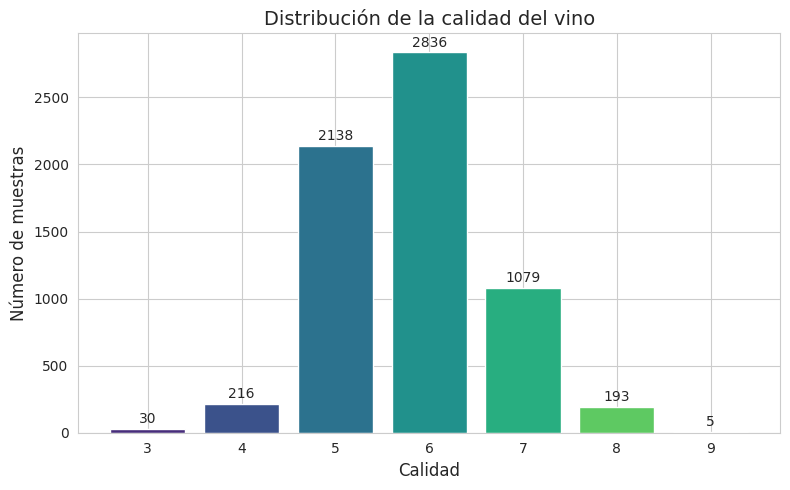

In [44]:
# Distribución de la variable objetivo (quality)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
quality_counts = df['quality'].value_counts().sort_index()
bars = ax.bar(quality_counts.index, quality_counts.values, color=sns.color_palette('viridis', len(quality_counts)))
ax.set_xlabel('Calidad', fontsize=12)
ax.set_ylabel('Número de muestras', fontsize=12)
ax.set_title('Distribución de la calidad del vino', fontsize=14)
ax.set_xticks(quality_counts.index)

# Poner el número encima de cada barra
for bar, val in zip(bars, quality_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Como se puede ver, la distribución de la calidad está claramente **desbalanceada**: la mayoría de los vinos tienen una calidad de 5, 6 o 7. Hay muy pocos vinos con calidades extremas (3, 4, 8 o 9). Esto es algo que hay que tener en cuenta porque puede afectar al rendimiento de los modelos de clasificación, sobre todo en las clases minoritarias.

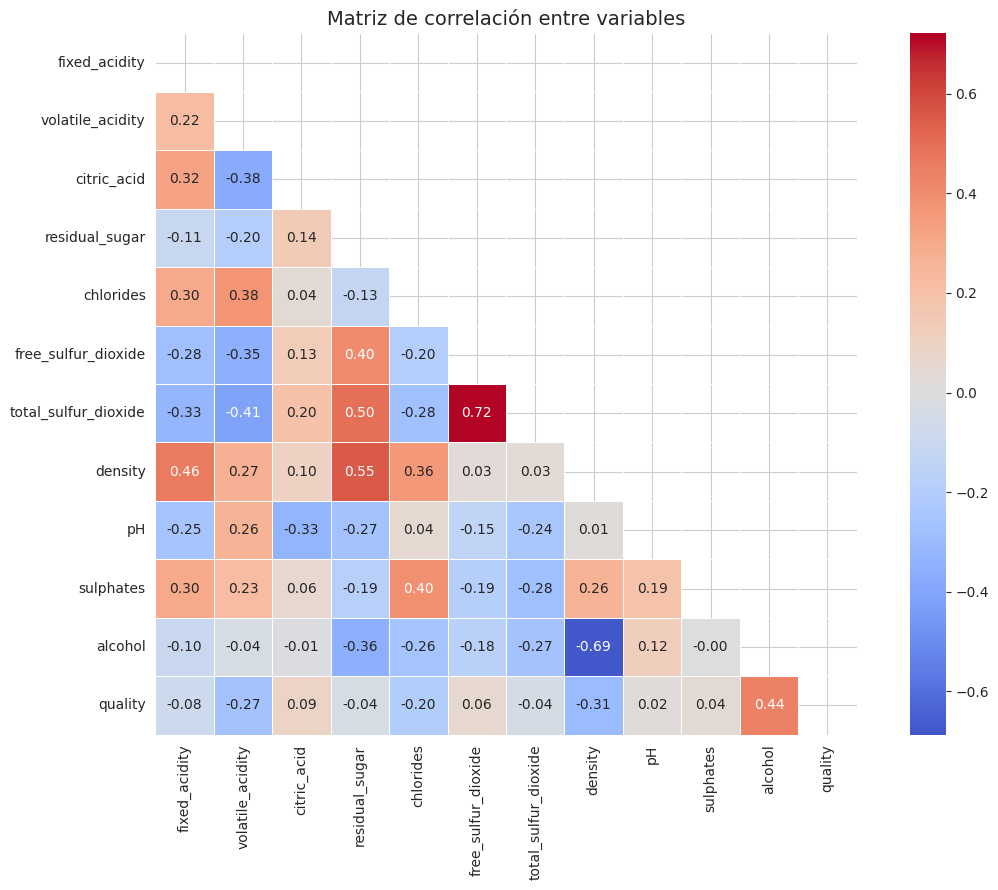

In [45]:
# Matriz de correlación
fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # triangulo superior
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlación entre variables', fontsize=14)
plt.tight_layout()
plt.show()

De la matriz de correlación podemos sacar varias cosas:
- El **alcohol** tiene la correlación más alta con la calidad (~0.44), lo cual tiene sentido ya que los vinos de mayor calidad tienden a tener más cuerpo.
- La **densidad** está bastante correlacionada negativamente con el alcohol, porque el alcohol es menos denso que el agua.
- La **volatile acidity** tiene correlación negativa con la calidad, lo que indica que los vinos con mayor acidez volátil suelen ser percibidos como de peor calidad (tiene sentido, la acidez volátil en exceso produce un sabor avinagrado).
- Hay correlaciones fuertes entre ciertas variables de entrada (como free/total sulfur dioxide o density/residual sugar), pero no voy a hacer selección de características por ahora.

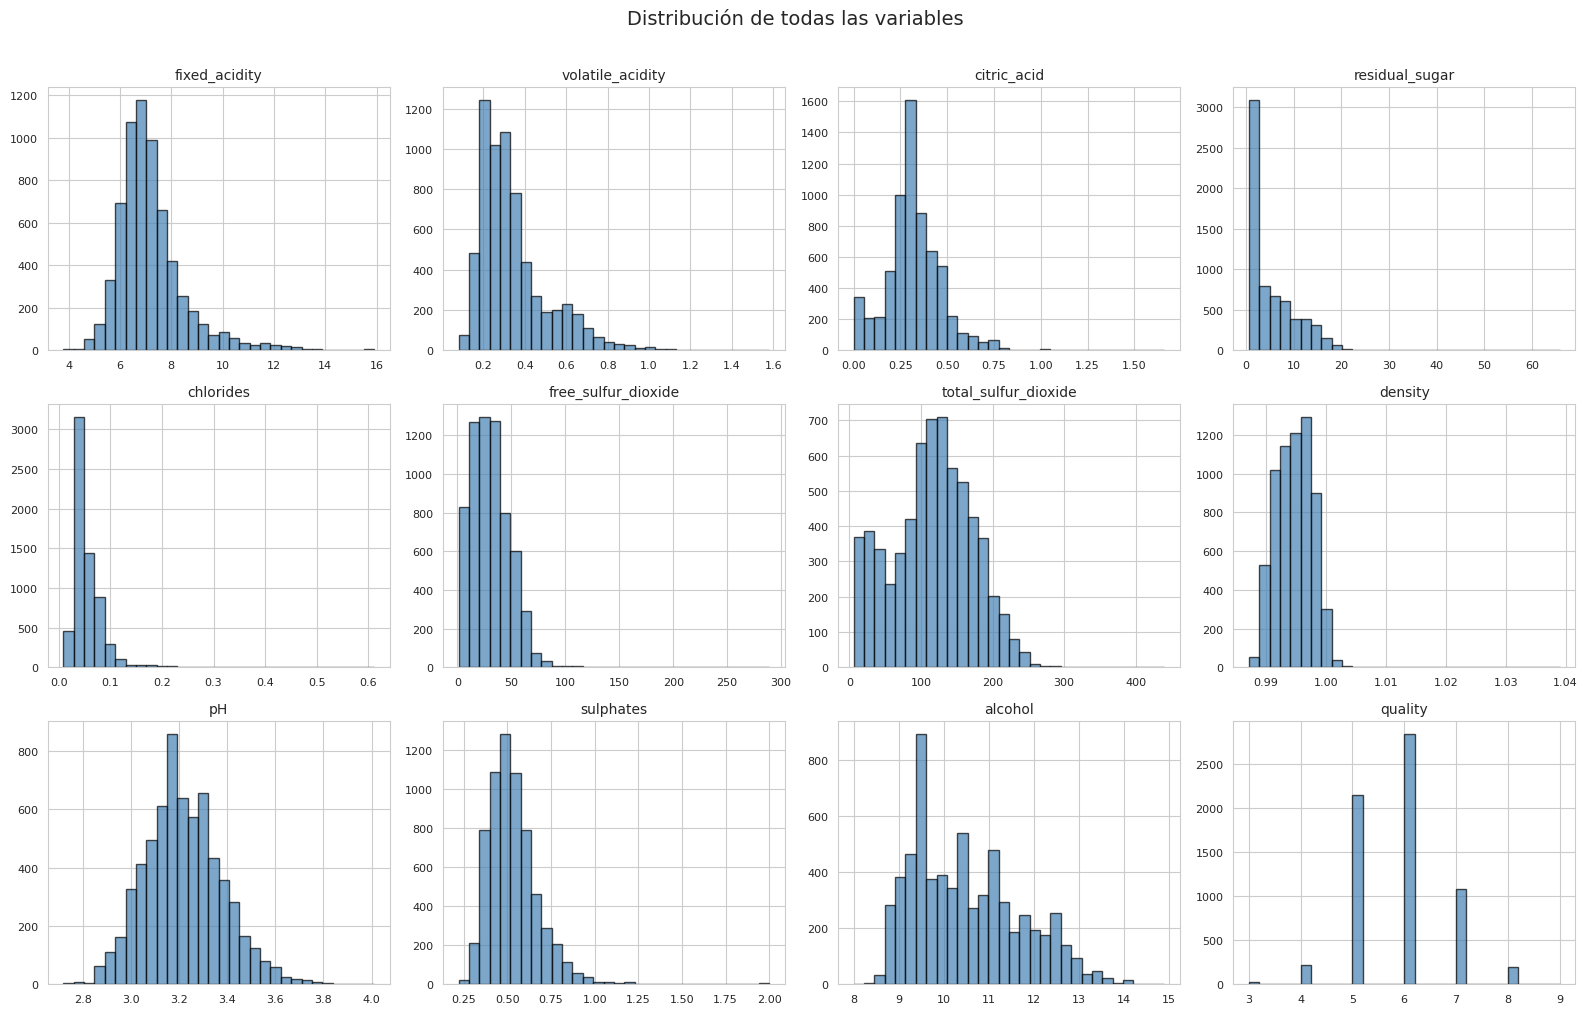

In [46]:
# Distribución de cada variable con histogramas
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Distribución de todas las variables', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Se observa que algunas variables como `residual_sugar`, `chlorides` y `sulphates` tienen distribuciones bastante sesgadas hacia la derecha (con colas largas), lo que podría tener impacto en modelos sensibles a la escala como SVM o KNN. Por eso más adelante vamos a estandarizar las variables.

## 4. Preprocesamiento de datos

Estos son los pasos de preparación antes de entrenar los modelos:
1. Separar features y target.
2. Dividir en conjuntos de entrenamiento (80%) y test (20%).
3. Escalar las variables con `StandardScaler` para que todas tengan media 0 y desviación estándar 1.

Es importante escalar porque SVM y KNN son sensibles a la magnitud de las variables. Random Forest no lo necesitaría, pero por coherencia uso los mismos datos para todos.

In [47]:
# Target como array plano
y_vals = y['quality'].values

# División train/test con estratificación para mantener la distribución de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y_vals, test_size=0.2, random_state=42, stratify=y_vals
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Conjunto de test: {X_test.shape[0]} muestras')
print(f'\nDistribución de clases en train:')
print(pd.Series(y_train).value_counts().sort_index())
print(f'\nDistribución de clases en test:')
print(pd.Series(y_test).value_counts().sort_index())

Conjunto de entrenamiento: 5197 muestras
Conjunto de test: 1300 muestras

Distribución de clases en train:
3      24
4     173
5    1710
6    2269
7     863
8     154
9       4
Name: count, dtype: int64

Distribución de clases en test:
3      6
4     43
5    428
6    567
7    216
8     39
9      1
Name: count, dtype: int64


In [48]:
# Escalado de las variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Datos escalados correctamente.')
print(f'Media de X_train_scaled (debería ser ~0): {X_train_scaled.mean(axis=0).round(4)}')
print(f'Std de X_train_scaled (debería ser ~1): {X_train_scaled.std(axis=0).round(4)}')

Datos escalados correctamente.
Media de X_train_scaled (debería ser ~0): [-0.  0.  0.  0.  0. -0.  0. -0.  0. -0. -0.]
Std de X_train_scaled (debería ser ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Modelos de Regresión

En esta sección voy a entrenar 3 modelos de regresión para predecir la calidad como variable continua. Para cada uno, haré una búsqueda de hiperparámetros con `GridSearchCV` (validación cruzada de 5 folds) y evaluaré usando **MAE**, **MSE** y **R²**.

He elegido estas tres métricas porque:
- **MAE** (Mean Absolute Error): mide el error medio absoluto, fácil de interpretar ("de media me equivoco X puntos").
- **MSE** (Mean Squared Error): penaliza más los errores grandes, útil para detectar predicciones muy desviadas.
- **R²**: indica qué proporción de la varianza de la calidad es explicada por el modelo (1 = perfecto, 0 = no explica nada).

### 5.1 Random Forest Regressor

In [49]:
# Random Forest Regressor con búsqueda de hiperparámetros
param_grid_rfr = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rfr = RandomForestRegressor(random_state=42)
grid_rfr = GridSearchCV(rfr, param_grid_rfr, cv=5, scoring='neg_mean_absolute_error',
                        n_jobs=-1, verbose=0)
grid_rfr.fit(X_train_scaled, y_train)

print('Mejores hiperparámetros:', grid_rfr.best_params_)
print(f'Mejor MAE en validación cruzada: {-grid_rfr.best_score_:.4f}')

Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Mejor MAE en validación cruzada: 0.4507


In [50]:
# Evaluación en test
rfr_best = grid_rfr.best_estimator_
y_pred_rfr = rfr_best.predict(X_test_scaled)

mae_rfr = mean_absolute_error(y_test, y_pred_rfr)
mse_rfr = mean_squared_error(y_test, y_pred_rfr)
r2_rfr = r2_score(y_test, y_pred_rfr)

print('=== Random Forest Regressor (Test) ===')
print(f'MAE:  {mae_rfr:.4f}')
print(f'MSE:  {mse_rfr:.4f}')
print(f'R²:   {r2_rfr:.4f}')

=== Random Forest Regressor (Test) ===
MAE:  0.4292
MSE:  0.3667
R²:   0.5196


Random Forest consigue unos resultados aceptables para empezar. El MAE nos dice que, de media, se equivoca en menos de medio punto de calidad, y el R² está en torno a 0.52, o sea que explica algo más de la mitad de la variabilidad. No está mal, pero tampoco es espectacular. Hay que tener en cuenta que la calidad del vino tiene un componente subjetivo importante — dos catadores pueden puntuar el mismo vino de forma distinta — así que hay un techo natural.

Vamos a ver si SVR y KNN consiguen mejorar estos números.

### 5.2 SVM Regressor (SVR)

In [51]:
# SVR con búsqueda de hiperparámetros
param_grid_svr = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto'],
    'epsilon': [0.05, 0.1, 0.2]
}

svr = SVR()
grid_svr = GridSearchCV(svr, param_grid_svr, cv=5, scoring='neg_mean_absolute_error',
                        n_jobs=-1, verbose=0)
grid_svr.fit(X_train_scaled, y_train)

print('Mejores hiperparámetros:', grid_svr.best_params_)
print(f'Mejor MAE en validación cruzada: {-grid_svr.best_score_:.4f}')

Mejores hiperparámetros: {'C': 10, 'epsilon': 0.05, 'gamma': 'auto', 'kernel': 'rbf'}
Mejor MAE en validación cruzada: 0.5118


In [52]:
# Evaluación en test
svr_best = grid_svr.best_estimator_
y_pred_svr = svr_best.predict(X_test_scaled)

mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print('=== SVR (Test) ===')
print(f'MAE:  {mae_svr:.4f}')
print(f'MSE:  {mse_svr:.4f}')
print(f'R²:   {r2_svr:.4f}')

=== SVR (Test) ===
MAE:  0.4975
MSE:  0.4563
R²:   0.4023


SVR es el que peor parado sale de los tres. Tiene el MAE más alto (~0.50) y el R² más bajo (~0.40). Esto puede deberse a que SVM busca un hiperplano o superficie de decisión óptima, y en problemas con relaciones complejas entre muchas variables no siempre es el planteamiento más adecuado. Además, SVR es bastante sensible a la elección de hiperparámetros (C, epsilon, gamma...), y aunque hemos hecho GridSearch, el espacio de búsqueda posible es enorme.

Queda KNN por probar, a ver si mejora.

### 5.3 KNN Regressor

In [53]:
# KNN Regressor con búsqueda de hiperparámetros
param_grid_knnr = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knnr = KNeighborsRegressor()
grid_knnr = GridSearchCV(knnr, param_grid_knnr, cv=5, scoring='neg_mean_absolute_error',
                         n_jobs=-1, verbose=0)
grid_knnr.fit(X_train_scaled, y_train)

print('Mejores hiperparámetros:', grid_knnr.best_params_)
print(f'Mejor MAE en validación cruzada: {-grid_knnr.best_score_:.4f}')

Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Mejor MAE en validación cruzada: 0.4252


In [54]:
# Evaluación en test
knnr_best = grid_knnr.best_estimator_
y_pred_knnr = knnr_best.predict(X_test_scaled)

mae_knnr = mean_absolute_error(y_test, y_pred_knnr)
mse_knnr = mean_squared_error(y_test, y_pred_knnr)
r2_knnr = r2_score(y_test, y_pred_knnr)

print('=== KNN Regressor (Test) ===')
print(f'MAE:  {mae_knnr:.4f}')
print(f'MSE:  {mse_knnr:.4f}')
print(f'R²:   {r2_knnr:.4f}')

=== KNN Regressor (Test) ===
MAE:  0.3939
MSE:  0.3638
R²:   0.5235


**KNN acaba siendo el mejor en regresión**, con el MAE más bajo (~0.39) y el R² más alto (~0.52), superando ligeramente a Random Forest. No me lo esperaba del todo, porque con 11 dimensiones la maldición de la dimensionalidad suele perjudicar a los métodos basados en distancias. Pero parece que la combinación de ponderación por distancia (`weights='distance'`) y la métrica manhattan le sienta bien a estos datos — probablemente porque las relaciones entre las variables fisicoquímicas y la calidad son relativamente "locales" (vinos con propiedades químicas similares tienden a tener calidades parecidas).

Vamos a ver la tabla comparativa para confirmar todo esto.

### 5.4 Comparación de modelos de regresión

In [55]:
# Tabla comparativa de regresión
resultados_reg = pd.DataFrame({
    'Modelo': ['Random Forest', 'SVR', 'KNN'],
    'MAE': [mae_rfr, mae_svr, mae_knnr],
    'MSE': [mse_rfr, mse_svr, mse_knnr],
    'R²': [r2_rfr, r2_svr, r2_knnr]
})

resultados_reg = resultados_reg.round(4)
print('=== Comparación de modelos de REGRESIÓN ===')
print(resultados_reg.to_string(index=False))

# Identificar el mejor
mejor_reg_idx = resultados_reg['MAE'].idxmin()
print(f'\n>>> Mejor modelo de regresión: {resultados_reg.loc[mejor_reg_idx, "Modelo"]} (menor MAE)')

=== Comparación de modelos de REGRESIÓN ===
       Modelo    MAE    MSE     R²
Random Forest 0.4292 0.3667 0.5196
          SVR 0.4975 0.4563 0.4023
          KNN 0.3939 0.3638 0.5235

>>> Mejor modelo de regresión: KNN (menor MAE)


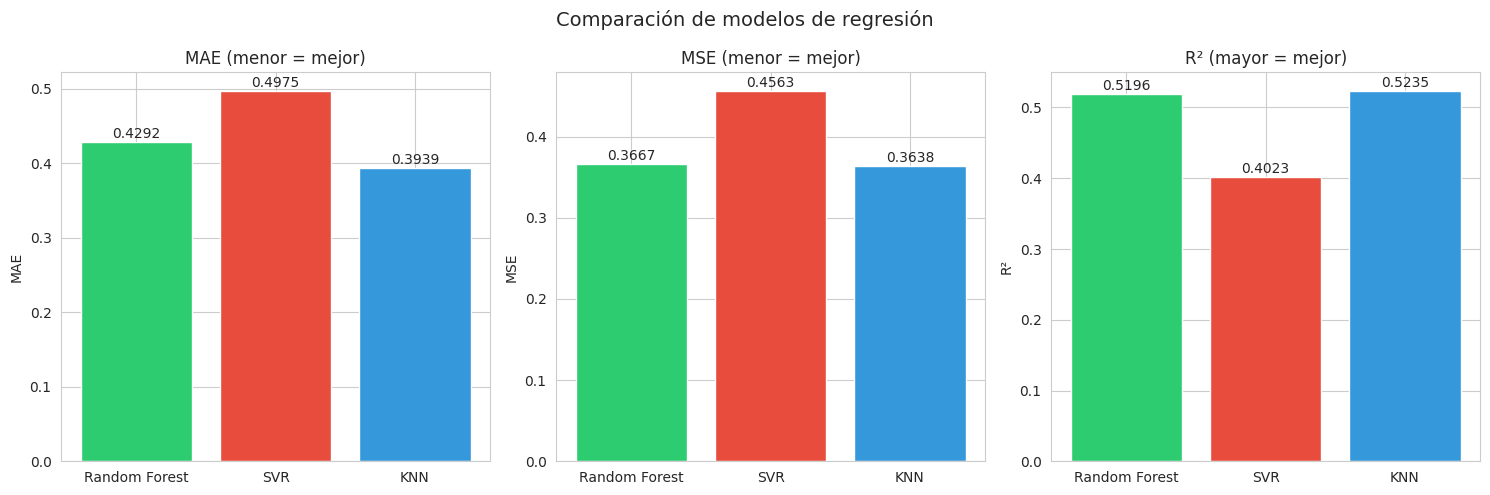

In [56]:
# Gráfico comparativo de métricas de regresión
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
modelos = resultados_reg['Modelo']
colores = ['#2ecc71', '#e74c3c', '#3498db']

# MAE
axes[0].bar(modelos, resultados_reg['MAE'], color=colores)
axes[0].set_title('MAE (menor = mejor)', fontsize=12)
axes[0].set_ylabel('MAE')
for i, v in enumerate(resultados_reg['MAE']):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

# MSE
axes[1].bar(modelos, resultados_reg['MSE'], color=colores)
axes[1].set_title('MSE (menor = mejor)', fontsize=12)
axes[1].set_ylabel('MSE')
for i, v in enumerate(resultados_reg['MSE']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

# R²
axes[2].bar(modelos, resultados_reg['R²'], color=colores)
axes[2].set_title('R² (mayor = mejor)', fontsize=12)
axes[2].set_ylabel('R²')
for i, v in enumerate(resultados_reg['R²']):
    axes[2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('Comparación de modelos de regresión', fontsize=14)
plt.tight_layout()
plt.show()

Los gráficos confirman lo que veníamos observando: **KNN** gana en regresión con el menor MAE y el mayor R², seguido muy de cerca por Random Forest. SVR se queda claramente atrás.

Es un resultado interesante porque a priori cabría esperar que Random Forest dominase (suele ser de lo mejor en datos tabulares), pero KNN con la ponderación por distancia y la métrica correcta ha demostrado ser más preciso para este problema concreto. Nos quedamos con KNN como nuestro mejor regresor y pasamos a la clasificación.

## 6. Modelos de Clasificación

Ahora vamos a tratar la calidad como variable categórica, es decir, cada valor (3, 4, 5, 6, 7, 8, 9) es una clase distinta. Para evaluar los modelos de clasificación usaré:

- **Accuracy**: porcentaje de predicciones correctas.
- **F1-score (weighted)**: media armónica de precisión y recall, ponderada por el número de muestras de cada clase. Es especialmente útil cuando las clases están desbalanceadas, como es nuestro caso.
- **Matriz de confusión**: para ver exactamente dónde se equivoca el modelo.

Uso el F1-score weighted en lugar del macro porque, como hemos visto, hay clases con muy pocas muestras y el macro le daría el mismo peso a todas.

### 6.1 Random Forest Classifier

In [57]:
# Random Forest Classifier con búsqueda de hiperparámetros
param_grid_rfc = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rfc = RandomForestClassifier(random_state=42)
grid_rfc = GridSearchCV(rfc, param_grid_rfc, cv=5, scoring='f1_weighted',
                        n_jobs=-1, verbose=0)
grid_rfc.fit(X_train_scaled, y_train)

print('Mejores hiperparámetros:', grid_rfc.best_params_)
print(f'Mejor F1-weighted en CV: {grid_rfc.best_score_:.4f}')

Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor F1-weighted en CV: 0.6540


In [58]:
# Evaluación en test
rfc_best = grid_rfc.best_estimator_
y_pred_rfc = rfc_best.predict(X_test_scaled)

acc_rfc = accuracy_score(y_test, y_pred_rfc)
f1_rfc = f1_score(y_test, y_pred_rfc, average='weighted')

print('=== Random Forest Classifier (Test) ===')
print(f'Accuracy:    {acc_rfc:.4f}')
print(f'F1-weighted: {f1_rfc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rfc))

=== Random Forest Classifier (Test) ===
Accuracy:    0.6962
F1-weighted: 0.6851

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.78      0.16      0.27        43
           5       0.75      0.71      0.73       428
           6       0.66      0.80      0.73       567
           7       0.69      0.58      0.63       216
           8       0.82      0.36      0.50        39
           9       0.00      0.00      0.00         1

    accuracy                           0.70      1300
   macro avg       0.53      0.37      0.41      1300
weighted avg       0.70      0.70      0.69      1300



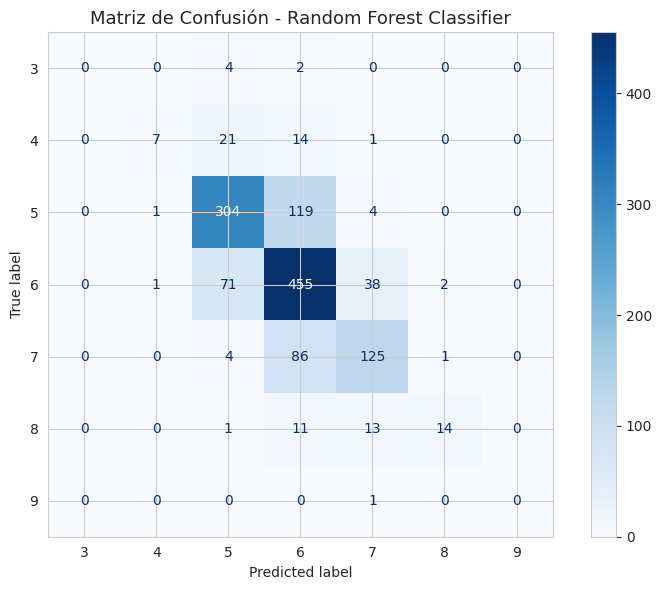

In [59]:
# Matriz de confusión Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rfc, ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusión - Random Forest Classifier', fontsize=13)
plt.tight_layout()
plt.show()

Random Forest vuelve a dar un buen resultado como clasificador. Si nos fijamos en la matriz de confusión, se ve que el modelo acierta bastante bien en las clases mayoritarias (5, 6 y 7), pero tiene problemas claros con las clases extremas (3, 4, 8, 9). Esto es consecuencia directa del desbalanceo que vimos en el EDA: con tan pocas muestras de esas clases, el modelo no tiene suficientes ejemplos de los que aprender.

El classification report también lo refleja: el recall de las clases minoritarias es bastante bajo.

### 6.2 SVM Classifier (SVC)

In [60]:
# SVC con búsqueda de hiperparámetros
param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svc = SVC(random_state=42)
grid_svc = GridSearchCV(svc, param_grid_svc, cv=5, scoring='f1_weighted',
                        n_jobs=-1, verbose=0)
grid_svc.fit(X_train_scaled, y_train)

print('Mejores hiperparámetros:', grid_svc.best_params_)
print(f'Mejor F1-weighted en CV: {grid_svc.best_score_:.4f}')

Mejores hiperparámetros: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Mejor F1-weighted en CV: 0.5661


In [61]:
# Evaluación en test
svc_best = grid_svc.best_estimator_
y_pred_svc = svc_best.predict(X_test_scaled)

acc_svc = accuracy_score(y_test, y_pred_svc)
f1_svc = f1_score(y_test, y_pred_svc, average='weighted')

print('=== SVM Classifier (Test) ===')
print(f'Accuracy:    {acc_svc:.4f}')
print(f'F1-weighted: {f1_svc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_svc))

=== SVM Classifier (Test) ===
Accuracy:    0.5908
F1-weighted: 0.5753

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.18      0.07      0.10        43
           5       0.63      0.62      0.62       428
           6       0.58      0.72      0.64       567
           7       0.57      0.41      0.48       216
           8       0.50      0.13      0.20        39
           9       0.00      0.00      0.00         1

    accuracy                           0.59      1300
   macro avg       0.35      0.28      0.29      1300
weighted avg       0.58      0.59      0.58      1300



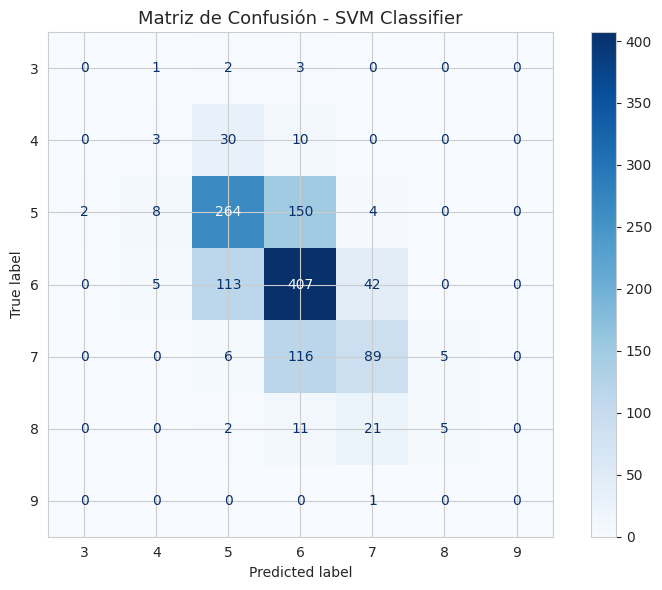

In [62]:
# Matriz de confusión SVM
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc, ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusión - SVM Classifier', fontsize=13)
plt.tight_layout()
plt.show()

SVM es el que peor resultados obtiene en clasificación, con un accuracy de ~0.59 y un F1-weighted de ~0.58, bastante por debajo de Random Forest. La matriz de confusión muestra que SVM tiende a concentrar mucho las predicciones en las clases 5 y 6, ignorando prácticamente las clases extremas. Esto puede deberse a que SVM tiene más dificultades para manejar problemas multiclase con clases desbalanceadas — al fin y al cabo, SVM fue pensado originalmente para clasificación binaria, y la extensión a múltiples clases (one-vs-one o one-vs-rest) no siempre es la más eficiente.

### 6.3 KNN Classifier

In [63]:
# KNN Classifier con búsqueda de hiperparámetros
param_grid_knnc = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knnc = KNeighborsClassifier()
grid_knnc = GridSearchCV(knnc, param_grid_knnc, cv=5, scoring='f1_weighted',
                         n_jobs=-1, verbose=0)
grid_knnc.fit(X_train_scaled, y_train)

print('Mejores hiperparámetros:', grid_knnc.best_params_)
print(f'Mejor F1-weighted en CV: {grid_knnc.best_score_:.4f}')

Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Mejor F1-weighted en CV: 0.6406


In [64]:
# Evaluación en test
knnc_best = grid_knnc.best_estimator_
y_pred_knnc = knnc_best.predict(X_test_scaled)

acc_knnc = accuracy_score(y_test, y_pred_knnc)
f1_knnc = f1_score(y_test, y_pred_knnc, average='weighted')

print('=== KNN Classifier (Test) ===')
print(f'Accuracy:    {acc_knnc:.4f}')
print(f'F1-weighted: {f1_knnc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knnc))

=== KNN Classifier (Test) ===
Accuracy:    0.6715
F1-weighted: 0.6595

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.75      0.07      0.13        43
           5       0.73      0.71      0.72       428
           6       0.65      0.74      0.69       567
           7       0.61      0.60      0.60       216
           8       0.78      0.36      0.49        39
           9       0.00      0.00      0.00         1

    accuracy                           0.67      1300
   macro avg       0.50      0.35      0.38      1300
weighted avg       0.67      0.67      0.66      1300



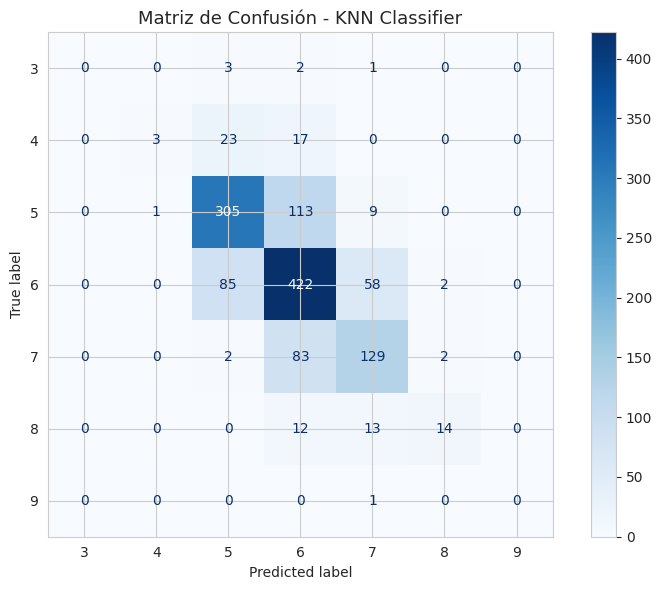

In [65]:
# Matriz de confusión KNN
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knnc, ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusión - KNN Classifier', fontsize=13)
plt.tight_layout()
plt.show()

KNN se coloca en segundo lugar en clasificación, con un accuracy de ~0.67 y un F1-weighted de ~0.66, por detrás de Random Forest pero claramente por encima de SVM. Resulta curioso que KNN funcione mejor en clasificación que SVM, cuando normalmente suele ser al revés. Probablemente tiene que ver con que KNN capta bien las relaciones "locales" del dataset — vinos con propiedades químicas similares tienen calidades similares — y eso le da ventaja frente a SVM a la hora de asignar la clase correcta.

La matriz de confusión sigue mostrando dificultades con las clases extremas, pero menos que SVM.

Veamos ahora la comparación conjunta para decidir cuál nos quedamos.

### 6.4 Comparación de modelos de clasificación

In [66]:
# Tabla comparativa de clasificación
resultados_clf = pd.DataFrame({
    'Modelo': ['Random Forest', 'SVM', 'KNN'],
    'Accuracy': [acc_rfc, acc_svc, acc_knnc],
    'F1-weighted': [f1_rfc, f1_svc, f1_knnc]
})

resultados_clf = resultados_clf.round(4)
print('=== Comparación de modelos de CLASIFICACIÓN ===')
print(resultados_clf.to_string(index=False))

# Identificar el mejor
mejor_clf_idx = resultados_clf['F1-weighted'].idxmax()
print(f'\n>>> Mejor modelo de clasificación: {resultados_clf.loc[mejor_clf_idx, "Modelo"]} (mayor F1-weighted)')

=== Comparación de modelos de CLASIFICACIÓN ===
       Modelo  Accuracy  F1-weighted
Random Forest    0.6962       0.6851
          SVM    0.5908       0.5753
          KNN    0.6715       0.6595

>>> Mejor modelo de clasificación: Random Forest (mayor F1-weighted)


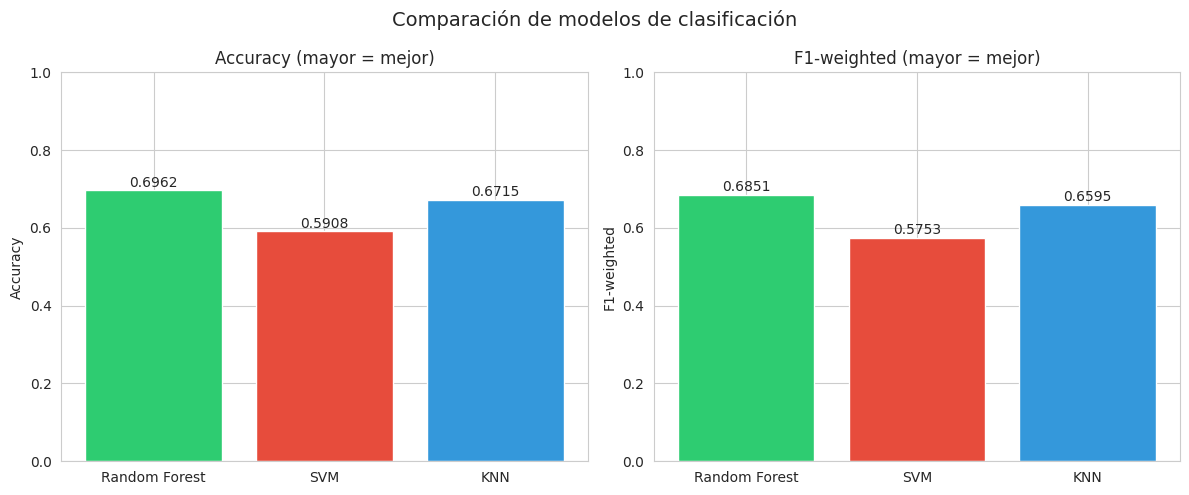

In [67]:
# Gráfico comparativo de clasificación
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
modelos_clf = resultados_clf['Modelo']

# Accuracy
axes[0].bar(modelos_clf, resultados_clf['Accuracy'], color=colores)
axes[0].set_title('Accuracy (mayor = mejor)', fontsize=12)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for i, v in enumerate(resultados_clf['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

# F1-weighted
axes[1].bar(modelos_clf, resultados_clf['F1-weighted'], color=colores)
axes[1].set_title('F1-weighted (mayor = mejor)', fontsize=12)
axes[1].set_ylabel('F1-weighted')
axes[1].set_ylim(0, 1)
for i, v in enumerate(resultados_clf['F1-weighted']):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('Comparación de modelos de clasificación', fontsize=14)
plt.tight_layout()
plt.show()

**Random Forest** gana en clasificación con el mejor accuracy (~0.70) y F1-weighted (~0.69). KNN queda segundo y SVM en último lugar. Es interesante ver cómo cambia el ranking respecto a regresión: en regresión KNN era el mejor y Random Forest segundo, pero en clasificación se invierten las posiciones.

Esto tiene cierto sentido: Random Forest, al usar muchos árboles de decisión, puede generar fronteras de decisión más complejas para separar las clases. KNN, en cambio, clasifica por "votación" de vecinos, lo que funciona bien pero es menos flexible que un ensemble de árboles. SVM es el que más sufre en ambos casos, probablemente porque este problema no se ajusta bien a la idea de separar clases por hiperplanos.

Nos quedamos con Random Forest como mejor clasificador y ahora toca la comparación final: el mejor de regresión (KNN) contra el mejor de clasificación (Random Forest).

## 7. Comparación final: Regresión vs Clasificación

Para poder comparar directamente el mejor modelo de regresión con el mejor de clasificación, necesitamos una métrica común. Lo que voy a hacer es **redondear las predicciones del modelo de regresión** al entero más cercano y compararlas con las clases reales, como si fuera un clasificador. Así puedo calcular accuracy y F1 para ambos y compararlos en igualdad de condiciones.

Esto tiene sentido porque la calidad es una puntuación entera, así que redondear la salida continua del regresor es una forma natural de convertirla a clase.

In [68]:
# Seleccionar las predicciones del mejor modelo de regresión
mejores_reg = {'Random Forest': y_pred_rfr, 'SVR': y_pred_svr, 'KNN': y_pred_knnr}
nombre_mejor_reg = resultados_reg.loc[mejor_reg_idx, 'Modelo']

# Mapeo de nombres para acceder a las predicciones
mapa_nombres_reg = {'Random Forest': 'Random Forest', 'SVR': 'SVR', 'KNN': 'KNN'}
pred_mejor_reg = mejores_reg[nombre_mejor_reg]

# Redondear predicciones de regresión y clipear a rango válido [3, 9]
pred_reg_rounded = np.clip(np.round(pred_mejor_reg), 3, 9).astype(int)

# Seleccionar predicciones del mejor clasificador
mejores_clf = {'Random Forest': y_pred_rfc, 'SVM': y_pred_svc, 'KNN': y_pred_knnc}
nombre_mejor_clf = resultados_clf.loc[mejor_clf_idx, 'Modelo']
pred_mejor_clf = mejores_clf[nombre_mejor_clf]

# Calcular métricas comparables
acc_reg_como_clf = accuracy_score(y_test, pred_reg_rounded)
f1_reg_como_clf = f1_score(y_test, pred_reg_rounded, average='weighted')

acc_mejor_clf = accuracy_score(y_test, pred_mejor_clf)
f1_mejor_clf = f1_score(y_test, pred_mejor_clf, average='weighted')

print('=' * 55)
print('COMPARACIÓN FINAL: REGRESIÓN vs CLASIFICACIÓN')
print('=' * 55)
print(f'\nMejor regresor:     {nombre_mejor_reg}')
print(f'  Accuracy (redondeado): {acc_reg_como_clf:.4f}')
print(f'  F1-weighted:           {f1_reg_como_clf:.4f}')
print(f'  MAE:                   {resultados_reg.loc[mejor_reg_idx, "MAE"]}')
print(f'  R²:                    {resultados_reg.loc[mejor_reg_idx, "R²"]}')
print(f'\nMejor clasificador: {nombre_mejor_clf}')
print(f'  Accuracy:              {acc_mejor_clf:.4f}')
print(f'  F1-weighted:           {f1_mejor_clf:.4f}')

COMPARACIÓN FINAL: REGRESIÓN vs CLASIFICACIÓN

Mejor regresor:     KNN
  Accuracy (redondeado): 0.6769
  F1-weighted:           0.6629
  MAE:                   0.3939
  R²:                    0.5235

Mejor clasificador: Random Forest
  Accuracy:              0.6962
  F1-weighted:           0.6851


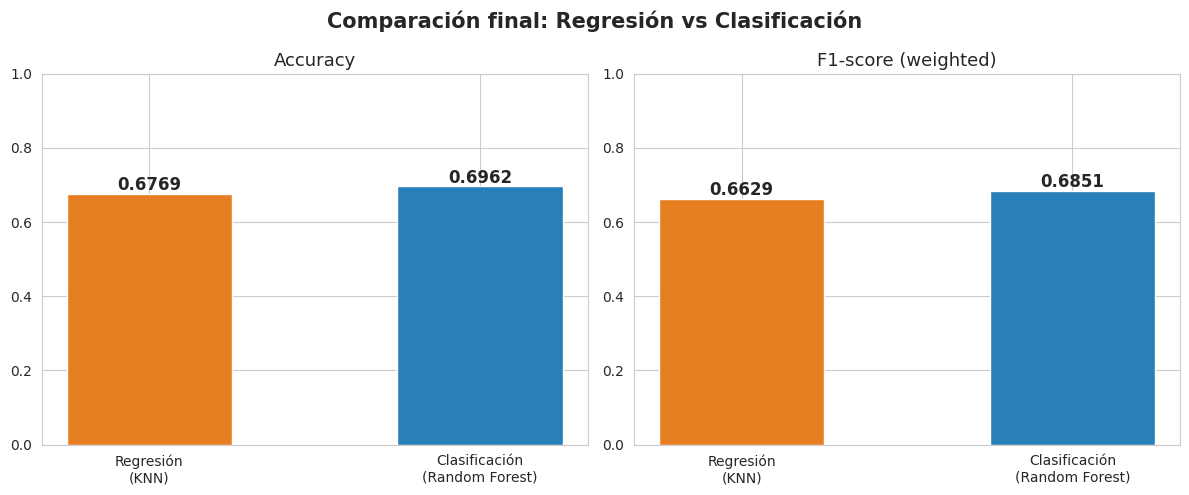

In [69]:
# Gráfico comparativo final
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

categorias = [f'Regresión\n({nombre_mejor_reg})', f'Clasificación\n({nombre_mejor_clf})']
colores_final = ['#e67e22', '#2980b9']

# Accuracy
acc_vals = [acc_reg_como_clf, acc_mejor_clf]
axes[0].bar(categorias, acc_vals, color=colores_final, width=0.5)
axes[0].set_title('Accuracy', fontsize=13)
axes[0].set_ylim(0, 1)
for i, v in enumerate(acc_vals):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

# F1-weighted
f1_vals = [f1_reg_como_clf, f1_mejor_clf]
axes[1].bar(categorias, f1_vals, color=colores_final, width=0.5)
axes[1].set_title('F1-score (weighted)', fontsize=13)
axes[1].set_ylim(0, 1)
for i, v in enumerate(f1_vals):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Comparación final: Regresión vs Clasificación', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

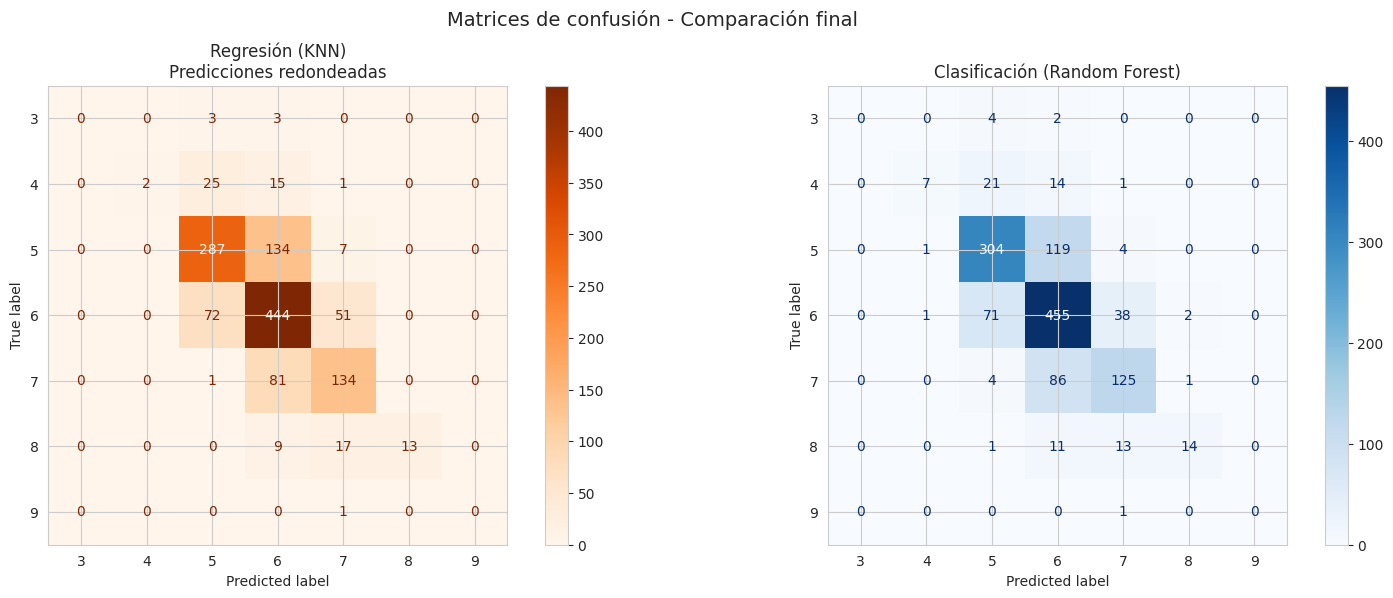

In [70]:
# Matrices de confusión lado a lado para la comparación final
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(y_test, pred_reg_rounded, ax=axes[0], cmap='Oranges')
axes[0].set_title(f'Regresión ({nombre_mejor_reg})\nPredicciones redondeadas', fontsize=12)

ConfusionMatrixDisplay.from_predictions(y_test, pred_mejor_clf, ax=axes[1], cmap='Blues')
axes[1].set_title(f'Clasificación ({nombre_mejor_clf})', fontsize=12)

plt.suptitle('Matrices de confusión - Comparación final', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Conclusiones

A lo largo de este cuaderno hemos abordado la predicción de la calidad del vino desde dos enfoques: regresión y clasificación. Probamos tres algoritmos en cada caso (Random Forest, SVM y KNN) y optimizamos sus hiperparámetros mediante GridSearchCV con validación cruzada de 5 folds.

Los resultados han sido distintos según el enfoque:

- **En regresión**, KNN ha sido el mejor modelo (MAE ≈ 0.39, R² ≈ 0.52), seguido de Random Forest y SVR en último lugar. KNN, con la ponderación por distancia y la métrica manhattan, aprovecha bien que vinos con propiedades químicas parecidas tienden a tener calidades similares.
- **En clasificación**, Random Forest ha sido el ganador (Accuracy ≈ 0.70, F1-weighted ≈ 0.69), seguido de KNN y SVM como peor modelo. Random Forest, al combinar muchos árboles de decisión, es capaz de generar fronteras de decisión más complejas para separar correctamente las clases.

Es interesante que el ranking cambie entre regresión y clasificación. Creo que esto se debe a la diferente naturaleza de ambas tareas: en regresión se busca predecir un valor exacto (donde la cercanía de los vecinos funciona bien), mientras que en clasificación se busca una frontera de decisión entre clases (donde los ensembles de árboles tienen ventaja).

En la **comparación final**, al redondear las predicciones del mejor regresor (KNN) y enfrentarlas a las del mejor clasificador (Random Forest), el clasificador obtiene un accuracy y F1 ligeramente superiores. Sin embargo, la diferencia es pequeña: ambos enfoques son válidos para este problema, ya que la calidad del vino es una variable ordinal que se sitúa a medio camino entre una variable continua y una categórica.

Uno de los principales retos ha sido el **desbalanceo de las clases**: la gran mayoría de vinos tienen calidad 5, 6 o 7, lo que dificulta la predicción de calidades extremas (3, 4, 8, 9). Además, la calidad del vino depende en parte de factores subjetivos del catador que no están recogidos en las variables fisicoquímicas, lo que pone un techo natural a la precisión alcanzable por cualquier modelo. Esto ya lo mencionan Cortez et al. (2009) en su artículo original sobre este dataset.

## 9. Bibliografía

- Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). *Modeling wine preferences by data mining from physicochemical properties.* Decision Support Systems, 47(4), 547-553. https://doi.org/10.1016/j.dss.2009.05.016

- UCI Machine Learning Repository — Wine Quality Dataset. https://archive.ics.uci.edu/dataset/186/wine+quality